In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import folium
from branca.utilities import color_brewer
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

/Users/diriczizsolt-csaba/Desktop/UPT/BDV/Project/.env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
DATASET_PATH = "data/openalex_ai_healthcare_publications_1980_2026_filtered_2.csv"

In [3]:
publications_df = pd.read_csv(DATASET_PATH)

### **3. Geographic Distribution of AI in Medicine Publications**

#### **3.1 Country Distribution Map**
This section analyzes the geographic distribution of scientific publications related to **Artificial Intelligence in Medicine**. Publications are grouped by country in order to identify which regions contribute the most to the field.

This perspective helps reveal the global research landscape of medical AI, highlighting leading countries, emerging contributors, and potential regional differences in research activity. Compared with the previous time-based analysis, this view focuses not on when the field grew, but on where most of the research output is concentrated.

In [4]:
WORLD_GEOJSON_URL = "https://raw.githubusercontent.com/python-visualization/folium-example-data/main/world_countries.json"
ISO_CODES_URL = "https://raw.githubusercontent.com/lukes/ISO-3166-Countries-with-Regional-Codes/master/all/all.csv"

In [5]:
papers_by_country = (
    publications_df[["openalex_id", "institution_countries"]] # Keep only paper ids and countries
      .dropna() # Remove rows where institution_countries is missing
      .assign(country=lambda x: x["institution_countries"].str.split(";")) # Split countries into a list
      .explode("country") # Explode the list into separate rows
      .assign(country=lambda x: x["country"].str.strip()) # Remove extra spaces from country names
      .drop_duplicates(["openalex_id", "country"]) # If a paper has multiple authors from the same country count only once
      .groupby("country") # Group rows by country
      .size() # Count papers per country
      .reset_index(name="paper_count") # Convert to a dataframe
      .sort_values("paper_count", ascending=False) # Order them descending by total paper count
)

In [6]:
papers_by_country.rename(columns={"country": "alpha-2"}, inplace=True)

In [ ]:
iso = pd.read_csv(ISO_CODES_URL)
iso_codes = iso[["alpha-2", "alpha-3", "name"]]
papers_by_country = papers_by_country.merge(iso_codes, on="alpha-2", how="left")
papers_by_country = papers_by_country.iloc[:, [3, 0, 2, 1]]

In [9]:
world = gpd.read_file(WORLD_GEOJSON_URL) # This gives us the coordinates
world = world.rename(columns={"id": "alpha-3"})

In [10]:
world_projected = world.to_crs(epsg=3857)

world["lon"] = world_projected.centroid.to_crs(epsg=4326).x
world["lat"] = world_projected.centroid.to_crs(epsg=4326).y

country_coords = world[["alpha-3", "lat", "lon"]]

In [11]:
papers_by_country = papers_by_country.merge(country_coords, on="alpha-3", how="left")

papers_by_country.head()

,name,alpha-2,alpha-3,paper_count,lat,lon
0,United States of America,US,USA,178560,51.260009,-119.450187
1,China,CN,CHN,170155,37.585669,104.206831
2,India,IN,IND,84944,23.250870,79.611822
3,United Kingdom of Great Britain and Northern I...,GB,GBR,67663,54.101937,-2.902717
4,Germany,DE,DEU,42152,51.246770,10.298018


In [12]:
bins = list(np.quantile(papers_by_country["paper_count"], [0, 0.4, 0.6, 0.75, 0.9, 0.95, 0.99, 1.0]))

world_map = folium.Map(location=[0, 0], zoom_start=2)

In [13]:
choropleth = folium.Choropleth(
    geo_data=WORLD_GEOJSON_URL,
    data=papers_by_country,
    columns=["alpha-3", "paper_count"],
    key_on="feature.id",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    bins=bins,                       
    legend_name="Number of Papers by Country",
).add_to(world_map)

for key in list(choropleth._children):
    if key.lower().startswith("color_map"):
        del choropleth._children[key]

colors = color_brewer("YlOrRd", n=len(bins) - 1)

def make_legend(bins, colors, title):
    rows = ""
    for i in reversed(range(len(colors))):      
        lo, hi = bins[i], bins[i + 1]
        label = f"{lo:,.0f} – {hi:,.0f}"
        rows += (
            f'<div style="display:flex;align-items:center;margin:2px 0;">'
            f'<span style="width:18px;height:14px;background:{colors[i]};'
            f'display:inline-block;margin-right:6px;border:0.5px solid #888;"></span>'
            f'<span>{label}</span></div>'
        )
    return (
        '<div style="position:fixed;bottom:28px;left:12px;z-index:9999;'
        'background:white;padding:10px 12px;border:1px solid #bbb;border-radius:4px;'
        'font-size:12px;font-family:sans-serif;box-shadow:0 1px 4px rgba(0,0,0,.3);">'
        f'<div style="font-weight:600;margin-bottom:6px;">{title}</div>{rows}</div>'
    )

world_map.get_root().html.add_child(
    folium.Element(make_legend(bins, colors, "Papers by country"))
)

world_map.save("figures/world_choropleth_papers_by_country.html")

world_map

#### **3.2 Yearly Publication Share of the Top Five Countries**
This section visualizes how the yearly publication share of the five most productive countries changes over time.

In [14]:
publications_country_year = (
    publications_df[["openalex_id", "publication_year", "institution_countries"]]
    .dropna()
    .assign(country=lambda x: x["institution_countries"].str.split(";"))
    .explode("country")
    .assign(country=lambda x: x["country"].str.strip())
    .drop_duplicates(["openalex_id", "publication_year", "country"])
)

In [26]:
top5_countries = papers_by_country["alpha-2"].to_list()[:5]

print(f"Top 5 countries are: {top5_countries}")

Top 5 countries are: ['US', 'CN', 'IN', 'GB', 'DE']


In [16]:
country_year_counts = (
    publications_country_year[publications_country_year["country"].isin(top5_countries)]
    .groupby(["publication_year", "country"])
    .size()
    .reset_index(name="paper_count")
)

In [17]:
country_year_counts.head()

,publication_year,country,paper_count
0,1980,DE,2
1,1980,GB,2
2,1980,US,12
3,1981,GB,2
4,1981,US,22


In [18]:
country_year_pivot = (
    country_year_counts
    .pivot(index="publication_year", columns="country", values="paper_count")
    .fillna(0)
    .sort_index()
)

In [19]:
country_year_pivot.head()

country,CN,DE,GB,IN,US
publication_year,,,,,
1980,0.0,2.0,2.0,0.0,12.0
1981,0.0,0.0,2.0,0.0,22.0
1982,0.0,2.0,3.0,0.0,24.0
1983,1.0,2.0,8.0,1.0,36.0
1984,0.0,3.0,5.0,0.0,41.0


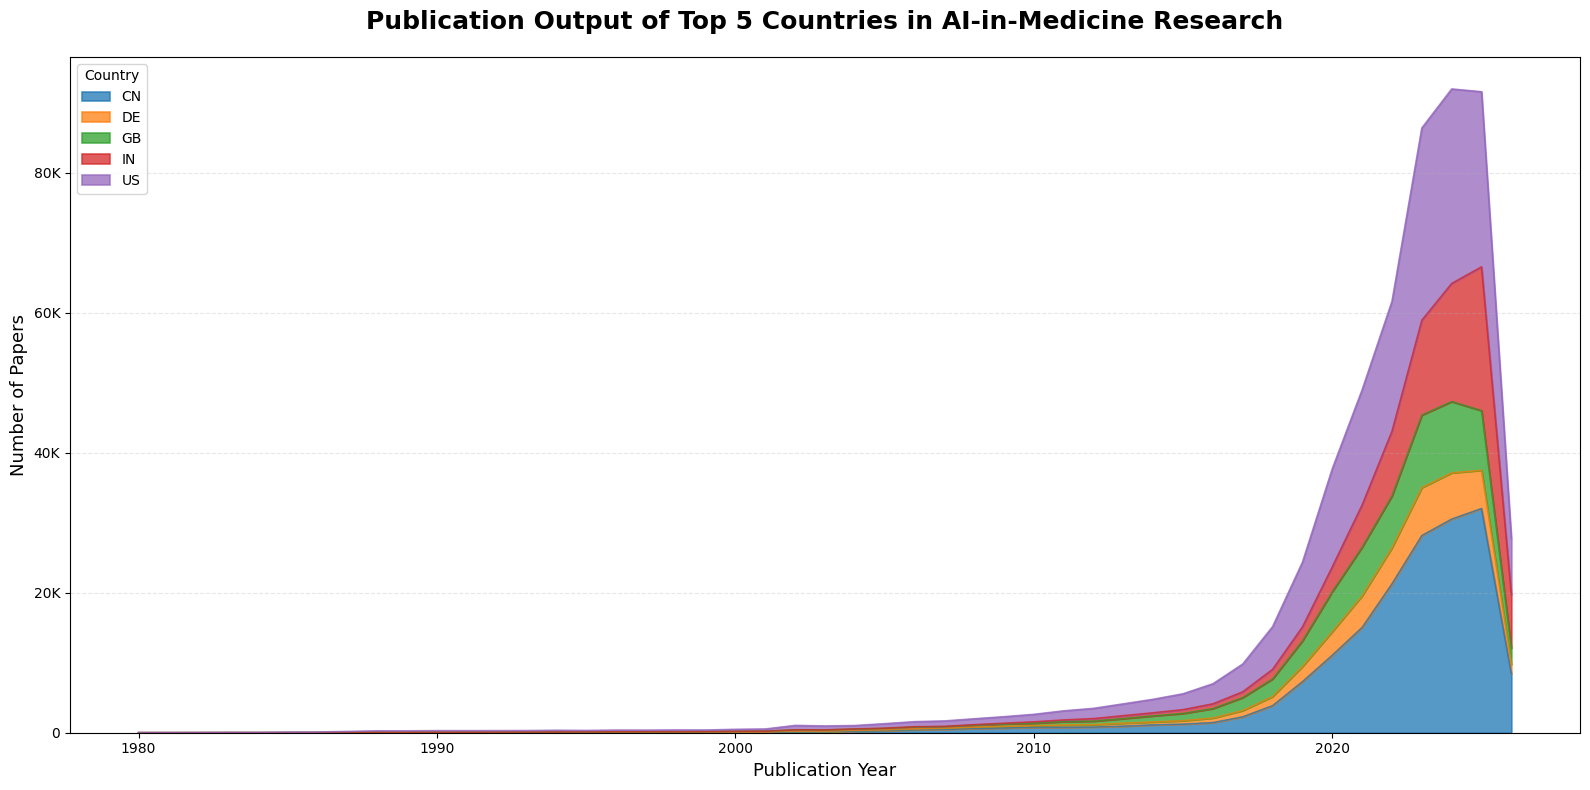

In [20]:
fig, ax = plt.subplots(figsize=(16, 8))

country_year_pivot.plot.area(ax=ax, alpha=0.75, linewidth=1.2)

ax.set_title("Publication Output of Top 5 Countries in AI-in-Medicine Research", fontsize=18, weight="bold", pad=20)
ax.set_xlabel("Publication Year", fontsize=13)
ax.set_ylabel("Number of Papers", fontsize=13)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(title="Country", loc="upper left")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K" if x >= 1000 else int(x)))

plt.tight_layout()
plt.show()

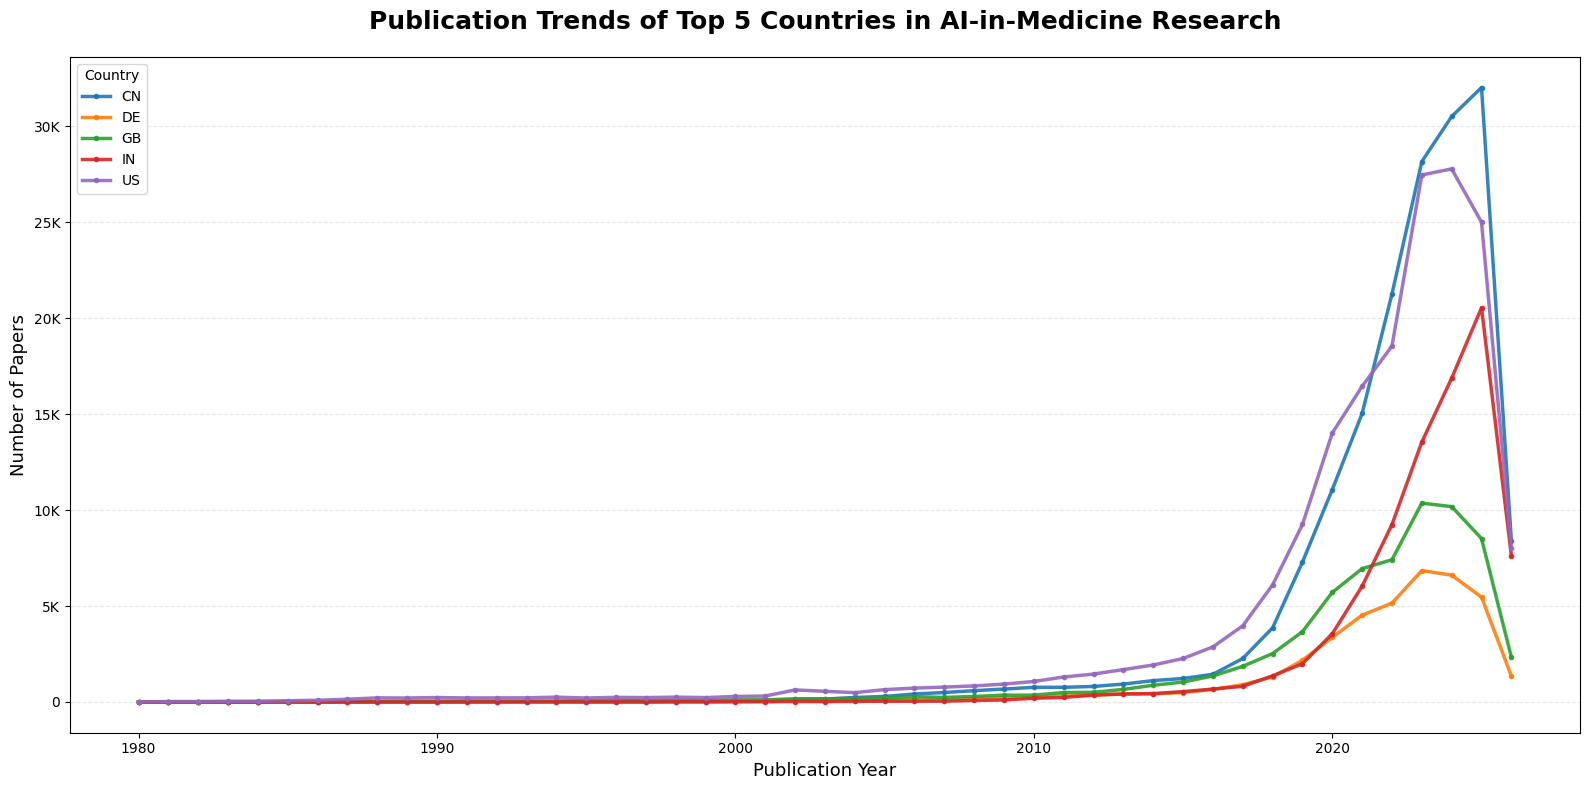

In [21]:
fig, ax = plt.subplots(figsize=(16, 8))

country_year_pivot.plot(ax=ax, linewidth=2.5, marker="o", markersize=3, alpha=0.9)

ax.set_title("Publication Trends of Top 5 Countries in AI-in-Medicine Research", fontsize=18, weight="bold", pad=20)

ax.set_xlabel("Publication Year", fontsize=13)
ax.set_ylabel("Number of Papers", fontsize=13)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(title="Country", loc="upper left")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K" if x >= 1000 else int(x)))

plt.tight_layout()
plt.show()

In [22]:
country_year_share = country_year_pivot.div(country_year_pivot.sum(axis=1), axis=0).fillna(0)

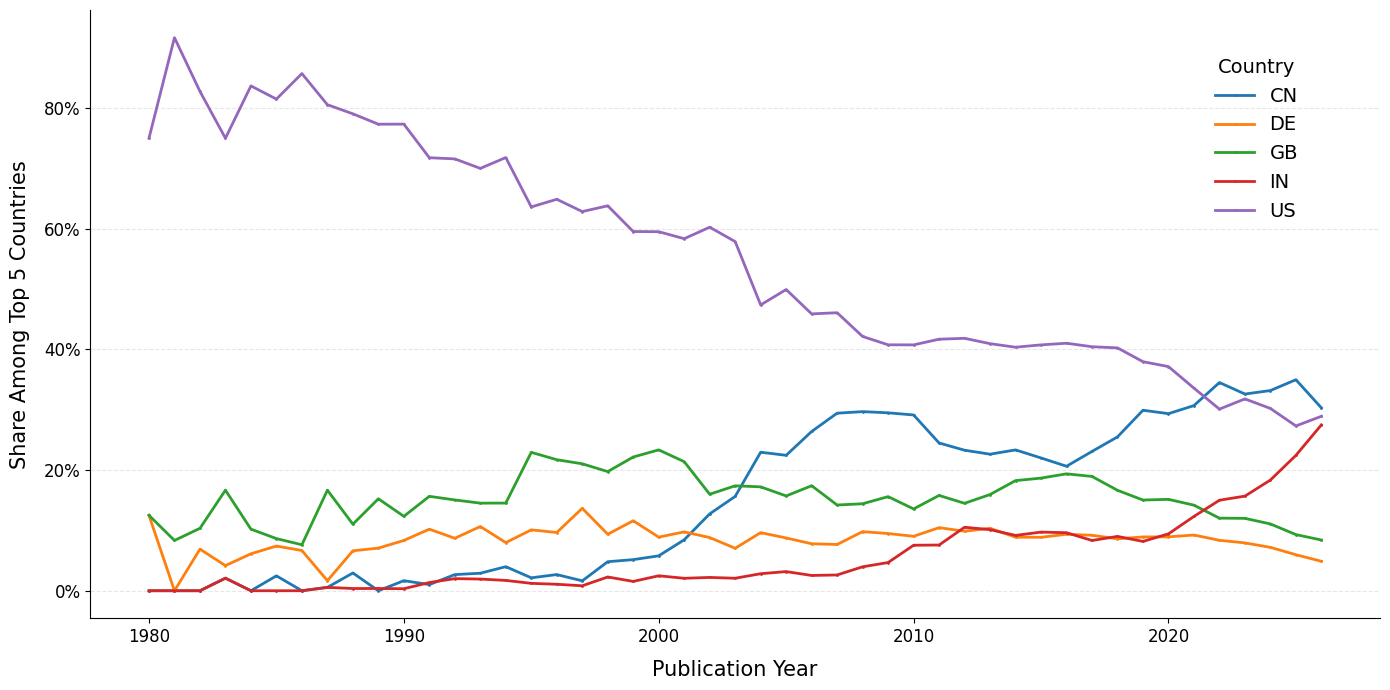

In [23]:
fig, ax = plt.subplots(figsize=(14, 7))

country_year_share.plot(ax=ax, linewidth=2, marker="o", markersize=1, alpha=1.0)

ax.set_xlabel("Publication Year", fontsize=15, labelpad=10)
ax.set_ylabel("Share Among Top 5 Countries", fontsize=15, labelpad=10)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Country", loc="upper right", title_fontsize=14, fontsize=14, frameon=False, bbox_to_anchor=(0.95, 0.95))
plt.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig("figures/top5_country_publication_share.png", dpi=300, bbox_inches="tight")
plt.show()